# Samuel - Mejora 9 - Tres regresiones logísticas con compuerta KNN y voto suave

**Proyecto - Parte 1: Machine Learning clásico**

**Estudiantes:**

[Nombre integrante 1] – [código]

[Nombre integrante 2] – [código]

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto

Después de ocho iteraciones los modelos del grupo se quedan alrededor de **0,90 de exactitud**. Este notebook prueba una idea distinta a las anteriores: en lugar de promediar modelos con pesos fijos, **dejar que un KNN decida cuánto pesa cada regresión logística en cada reseña**.

La idea tiene tres piezas:

1. **Tres regresiones logísticas "una contra el resto"**: una que separa `positivo` de `no positivo` (neutral o negativo), otra que separa `neutral` de `no neutral` y otra que separa `negativo` de `no negativo`. Se construyen con el mejor modelo del grupo, **Naive Bayes mezclado con regresión logística (NB-LR, Mejora 7)**: cada atributo se pondera con la razón de Naive Bayes de su clase antes de entrenar la regresión.
2. **Un KNN con distancia coseno** que lee la reseña por su cuenta, calcula una probabilidad para cada clase y **elige la de mayor probabilidad**.
3. **Un voto suave ponderado**: se promedian las probabilidades de las tres regresiones, pero la regresión de la clase que eligió el KNN recibe el mayor peso. Si el KNN dice "positivo", pesa más la regresión de `positivo`.

La pregunta es si esta votación predice mejor que los modelos que ya tenemos (regresión logística, NB-LR, dos etapas + NB-LR y la votación suave de los dos mejores de la Mejora 8).

La estructura sigue la de la Mejora 8:

| Paso | Sección de este notebook |
|:---|:---|
| Partición 60/20/20 estratificada, igual a la de la Mejora 8 (el conjunto de prueba solo se usa al final) | 2 |
| Preprocesamiento y representación de los notebooks anteriores | 3 |
| Las tres regresiones logísticas (NB-LR) y su ablación sin Naive Bayes | 4 |
| El KNN con distancia coseno que hace de compuerta | 5 |
| La mezcla: voto suave ponderado, elección del peso y variantes | 6 |
| Diagnóstico: cuándo ayuda y cuándo estorba la compuerta, y su techo | 7 |
| Sesgo y varianza | 8 |
| Comparación en validación con los modelos que ya teníamos | 9 |
| Evaluación en el conjunto de prueba (una sola vez) | 10 |
| Modelo final y predicciones para la competencia | 11 |

## Requisitos de la guía

| Requisito | Cómo se cumple |
|:---|:---|
| No usar aprendizaje profundo, transformers ni embeddings preentrenados. | No se usa ninguno. Todo se basa en bolsas de palabras, TF-IDF y n-gramas. |
| Usar únicamente modelos de scikit-learn. | Los clasificadores son de scikit-learn. `TresRegresionesLogisticas`, `PonderadorNB` y `ClasificadorCompuertaKNN` son clases propias que solo combinan `LogisticRegression` y `KNeighborsClassifier`. |
| No usar `eval.csv` para entrenar. | `eval.csv` solo se usa para generar el envío a la competencia. |
| Resultados replicables. | Semillas fijas, versiones en `requirements.txt` y todo el flujo en este notebook (sección 14). |

## 1. Importación de librerías

In [1]:
import os
import re
import time
import unicodedata
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse

try:
    from nltk.stem import SnowballStemmer
except ImportError:
    %pip install nltk
    from nltk.stem import SnowballStemmer

from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, ConfusionMatrixDisplay, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, label_binarize

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 180)

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']
INICIO_NOTEBOOK = time.time()

# Rutas del proyecto (este notebook está en la carpeta notebooks/)
RUTA_DATOS = os.path.join('..', 'data')
RUTA_MODELOS = os.path.join('..', 'models')
RUTA_ENVIOS = os.path.join('..', 'submissions')
os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_ENVIOS, exist_ok=True)

## 2. Datos y partición en entrenamiento, validación y prueba

Se usa **exactamente la misma partición de la Mejora 8** (60% entrenamiento, 20% validación y 20% prueba, estratificada y con la misma semilla), así que las cifras de este notebook se pueden comparar con las de aquel:

- **Entrenamiento (7.200):** para ajustar los modelos, buscar hiperparámetros con validación cruzada y generar predicciones "fuera de muestra".
- **Validación (2.400):** para comparar modelos y elegir el peso de la compuerta.
- **Prueba (2.400):** se usa una sola vez, al final (sección 10).

Con 2.400 reseñas, el error estándar de una exactitud cercana a 0,90 es de unos 0,6 puntos, así que diferencias menores a eso entre modelos deben leerse con cuidado.

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
muestra_envio = pd.read_csv(os.path.join(RUTA_DATOS, 'sample_submission.csv'))

print('train:', train.shape, '| eval:', evaluacion.shape, '| sample_submission:', muestra_envio.shape)
print('Distribución de clases en train:')
display(train['label'].value_counts(normalize=True).reindex(ORDEN_CLASES).round(3).to_frame('proporción'))

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)
Distribución de clases en train:


,proporción
label,
negativo,0.351
neutral,0.298
positivo,0.351


In [3]:
X = train[['text']]
y = train['label']

# 60% entrenamiento, 20% validación y 20% prueba, de forma estratificada (como en la Actividad 2 de la práctica)
X_resto, X_test, y_resto, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_resto, y_resto, test_size=0.25, stratify=y_resto, random_state=RANDOM_STATE)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Entrenamiento:', X_train.shape, '| Validación:', X_val.shape, '| Prueba:', X_test.shape)
pd.DataFrame({'entrenamiento': y_train.value_counts(normalize=True), 'validación': y_val.value_counts(normalize=True),
              'prueba': y_test.value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3)

Entrenamiento: (7200, 1) | Validación: (2400, 1) | Prueba: (2400, 1)


,entrenamiento,validación,prueba
label,,,
negativo,0.351,0.351,0.351
neutral,0.298,0.298,0.298
positivo,0.351,0.351,0.351


## 3. Preprocesamiento y representación

Se reutilizan, sin cambios, las celdas de la Mejora 8: limpieza del texto (minúsculas, sin tildes, signos ni números, con stemming), representación por bloques (texto completo, última oración y cláusula final con la corrección de la Mejora 7), bolsas binarias con marcado de negación, la clase `NBRegresionLogistica`, el modelo en dos etapas con NB-LR (solo se usa como referencia para comparar) y las funciones de métricas.

Una sola diferencia con la Mejora 8: en `ModeloDosEtapasNBLR` la regresión logística L1 con `liblinear` se envuelve en `OneVsRestClassifier`. Es lo mismo que hacía `liblinear` con tres clases (una regresión por clase), pero así el código también corre en scikit-learn 1.8, donde `liblinear` ya no acepta más de dos clases.

In [4]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


# Conectores que introducen la opinión que se impone sobre la anterior
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


def extraer_clausula_final(textos, stemming=True):
    salida = []
    for t in textos:
        ultima = quitar_tildes(separar_oraciones(t)[-1].lower())
        salida.append(limpiar_texto(re.split(CONECTORES, ultima)[-1], stemming=stemming))
    return salida


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')


def construir_representacion(bloques=('completo', 'ultima', 'clausula'), rango=(1, 2)):
    extractores = {'completo': extraer_completo,
                   'ultima': extraer_ultima,
                   'clausula': extraer_clausula_final}
    return ColumnTransformer([bloque_tfidf(b, extractores[b], rango) for b in bloques])

In [5]:
# "al final de cuentas" y "a fin de cuentas" suelen ser muletillas al final de la frase, no conectores.
# Se deja de cortar ahí y, si el corte deja un fragmento de menos de 3 palabras, se toma el anterior.
CONECTORES_CORREGIDOS = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|al final(?! de cuentas))\b'


def ultimo_fragmento(oracion, min_palabras=3):
    partes = [p for p in re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower())) if len(p.split()) >= min_palabras]
    return partes[-1] if partes else oracion


def extraer_clausula_corregida(textos, stemming=True):
    return [limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]), stemming=stemming) for t in textos]


def construir_representacion_corregida(rango=(1, 2)):
    return ColumnTransformer([bloque_tfidf('completo', extraer_completo, rango),
                              bloque_tfidf('ultima', extraer_ultima, rango),
                              bloque_tfidf('clausula', extraer_clausula_corregida, rango)])

In [6]:
def construir_bolsas_binarias(rango=(1, 2)):
    # Los mismos tres bloques del notebook principal, pero con presencia/ausencia de cada n-grama en lugar de TF-IDF
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima, 'clausula': extraer_clausula_corregida}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])


class NBRegresionLogistica(ClassifierMixin, BaseEstimator):
    """Regresión logística sobre atributos ponderados con la razón de Naive Bayes (NB-LR).

    Para cada clase (una contra el resto) cada atributo se multiplica por
    log(P(atributo | clase) / P(atributo | resto)), calculado con suavizado alpha como en
    MultinomialNB, y sobre esos atributos se entrena una regresión logística.
    """

    def __init__(self, C=0.3, alpha=1.0):
        self.C = C
        self.alpha = alpha

    def fit(self, X, y):
        X = sparse.csr_matrix(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.razones_, self.modelos_ = [], []
        for clase in self.classes_:
            es_clase = y == clase
            p = self.alpha + np.asarray(X[es_clase].sum(axis=0)).ravel()
            q = self.alpha + np.asarray(X[~es_clase].sum(axis=0)).ravel()
            razon = np.log((p / p.sum()) / (q / q.sum()))
            modelo = LogisticRegression(C=self.C, max_iter=3000)
            modelo.fit(X.multiply(razon).tocsr(), es_clase.astype(int))
            self.razones_.append(razon)
            self.modelos_.append(modelo)
        return self

    def predict_proba(self, X):
        X = sparse.csr_matrix(X, dtype=float)
        P = np.column_stack([m.predict_proba(X.multiply(r).tocsr())[:, 1]
                             for m, r in zip(self.modelos_, self.razones_)])
        return P / P.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


# Marcado del alcance de la negación (Mejora 5 de la rama pruebas1) sobre la cláusula corregida
NEGADORES = {'no', 'nunca', 'jamas', 'tampoco', 'ni', 'sin'}


def marcar_negacion(fragmento):
    salida = []
    for clausula in re.split(r'[.,;:!?()]+|' + CONECTORES_CORREGIDOS, fragmento):
        pieza = re.sub(r'\d+', ' ', re.sub(r'[^\w\s]', ' ', clausula))
        negando = False
        for palabra in pieza.split():
            if palabra in NEGADORES:
                negando = True
                salida.append(raiz(palabra))
                continue
            salida.append(raiz(palabra) + '_neg' if negando else raiz(palabra))
    return ' '.join(salida)


def extraer_ultima_negacion(textos):
    return [marcar_negacion(quitar_tildes(separar_oraciones(t)[-1].lower())) for t in textos]


def extraer_clausula_corregida_negacion(textos):
    return [marcar_negacion(ultimo_fragmento(separar_oraciones(t)[-1])) for t in textos]


def bolsas_binarias_negacion():
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima_negacion,
                   'clausula': extraer_clausula_corregida_negacion}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=(1, 2), binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])

In [7]:
K_ULTIMOS = 4          # cuántos de los últimos trozos se usan como atributos
N_INICIOS = 12         # cuántos comienzos de oración frecuentes se usan como atributos


def separar_trozos(texto):
    """Parte cada oración en trozos usando los conectores de contraste.
    Devuelve una lista de (trozo, tras_conector); tras_conector vale 1 si el trozo viene después de un conector."""
    trozos = []
    for oracion in separar_oraciones(texto):
        partes = re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower()))
        for i, parte in enumerate(partes):
            if parte.strip():
                trozos.append((parte.strip(), int(i > 0)))
    return trozos


def entrenar_etapa1(textos, etiquetas, C):
    trozos, etiquetas_trozos = [], []
    for texto, etiqueta in zip(textos, etiquetas):
        for trozo, _ in separar_trozos(texto):
            trozos.append(limpiar_texto(trozo))
            etiquetas_trozos.append(etiqueta)    # cada trozo hereda la etiqueta de su reseña
    vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    clasificador = LogisticRegression(C=C, max_iter=2000)
    clasificador.fit(vectorizador.fit_transform(trozos), etiquetas_trozos)
    return vectorizador, clasificador


def comienzo_oracion(oracion):
    palabras = re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).split()
    return ' '.join(palabras[:2])


def comienzos_frecuentes(textos, n=N_INICIOS):
    conteo = Counter(comienzo_oracion(o) for t in textos for o in separar_oraciones(t)[1:])
    return [c for c, _ in conteo.most_common(n)]


class ModeloDosEtapasNBLR(ClassifierMixin, BaseEstimator):
    """Modelo en dos etapas de la Mejora 1 al que se le agregan las probabilidades de NB-LR.

    Etapa 1: puntúa cada trozo de la reseña (probabilidad de negativo, neutral y positivo).
    Etapa 2: regresión logística sobre los puntajes de los últimos trozos, las probabilidades de los
    modelos por bloques (regresión logística, Naive Bayes y NB-LR) y el comienzo de las oraciones con opinión.
    """

    def __init__(self, C_etapa1=3, C_etapa2=1, C_nblr=0.3, alpha_nblr=1.0, n_particiones=5, random_state=42):
        self.C_etapa1 = C_etapa1
        self.C_etapa2 = C_etapa2
        self.C_nblr = C_nblr
        self.alpha_nblr = alpha_nblr
        self.n_particiones = n_particiones
        self.random_state = random_state

    def _entrenar_componentes(self, textos, etiquetas):
        datos = pd.DataFrame({'text': textos.values})
        representacion = construir_representacion_corregida().fit(datos)
        matriz = representacion.transform(datos)
        # OneVsRestClassifier reproduce lo que hacía liblinear con varias clases (una regresión por clase) y sigue
        # funcionando en scikit-learn 1.8, donde liblinear ya no admite más de dos clases
        regresion = OneVsRestClassifier(LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                                           random_state=RANDOM_STATE)).fit(matriz, etiquetas)
        bayes = MultinomialNB(alpha=0.3).fit(matriz, etiquetas)
        nblr = Pipeline([('rep', construir_bolsas_binarias()),
                         ('modelo', NBRegresionLogistica(C=self.C_nblr, alpha=self.alpha_nblr))]).fit(datos, etiquetas)
        vectorizador, clasificador = entrenar_etapa1(textos, etiquetas, self.C_etapa1)
        return {'representacion': representacion, 'regresion': regresion, 'bayes': bayes, 'nblr': nblr,
                'vectorizador': vectorizador, 'clasificador': clasificador}

    def _caracteristicas(self, textos, comp):
        datos = pd.DataFrame({'text': textos.values})
        matriz = comp['representacion'].transform(datos)
        prob_regresion = comp['regresion'].predict_proba(matriz)
        prob_bayes = comp['bayes'].predict_proba(matriz)
        prob_nblr = comp['nblr'].predict_proba(datos)

        trozos_por_texto = [separar_trozos(t) for t in textos]
        oraciones_por_texto = [separar_oraciones(t) for t in textos]
        probs_trozos = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(trozo) for lista in trozos_por_texto for trozo, _ in lista]))
        probs_oraciones = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(o) for lista in oraciones_por_texto for o in lista]))

        filas = []
        ini_t = ini_o = 0
        for k in range(len(textos)):
            trozos, oraciones = trozos_por_texto[k], oraciones_por_texto[k]
            P = probs_trozos[ini_t:ini_t + len(trozos)]
            Po = probs_oraciones[ini_o:ini_o + len(oraciones)]
            ini_t += len(trozos)
            ini_o += len(oraciones)

            fila = list(prob_regresion[k])
            for j in range(1, K_ULTIMOS + 1):
                if j <= len(trozos):
                    fila += list(P[-j]) + [trozos[-j][1]]
                else:
                    fila += [0, 0, 0, 0]
            polaridad = P[:, 2] - P[:, 0]
            con_opinion = np.where(P[:, 1] < 0.5)[0]
            fila += [polaridad[con_opinion[-1]] if len(con_opinion) > 0 else 0,
                     polaridad[con_opinion[-2]] if len(con_opinion) > 1 else 0,
                     polaridad[con_opinion[0]] if len(con_opinion) > 0 else 0,
                     len(con_opinion), P[:, 2].max(), P[:, 0].max(), P[:, 1].mean(), len(trozos)]
            fila += list(prob_bayes[k])
            oraciones_con_opinion = np.where(Po[:, 1] < 0.5)[0]
            for pos in [-1, -2]:
                comienzo = ''
                if len(oraciones_con_opinion) >= -pos:
                    comienzo = comienzo_oracion(oraciones[oraciones_con_opinion[pos]])
                fila += [int(comienzo == c) for c in self.comienzos_]
            fila += list(prob_nblr[k])
            filas.append(fila)
        return np.array(filas)

    def fit(self, X, y):
        textos = pd.Series(np.asarray(X['text']))
        etiquetas = pd.Series(np.asarray(y))
        self.classes_ = np.array(sorted(etiquetas.unique()))
        self.comienzos_ = comienzos_frecuentes(textos)

        # Atributos de la etapa 2 calculados fuera de muestra (validación cruzada interna)
        particiones = StratifiedKFold(n_splits=self.n_particiones, shuffle=True, random_state=self.random_state)
        caracteristicas = None
        for idx_ent, idx_val in particiones.split(textos, etiquetas):
            comp = self._entrenar_componentes(textos.iloc[idx_ent], etiquetas.iloc[idx_ent])
            fila_val = self._caracteristicas(textos.iloc[idx_val], comp)
            if caracteristicas is None:
                caracteristicas = np.zeros((len(textos), fila_val.shape[1]))
            caracteristicas[idx_val] = fila_val

        self.etapa2_ = Pipeline([('escala', StandardScaler()),
                                 ('modelo', LogisticRegression(C=self.C_etapa2, max_iter=3000))])
        self.etapa2_.fit(caracteristicas, etiquetas)
        self.componentes_ = self._entrenar_componentes(textos, etiquetas)
        return self

    def predict_proba(self, X):
        textos = pd.Series(np.asarray(X['text']))
        return self.etapa2_.predict_proba(self._caracteristicas(textos, self.componentes_))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

In [8]:
def metricas(y_real, prob=None, pred=None):
    """Exactitud, precisión, sensibilidad y F1 (promedio macro); AUC y AP si hay probabilidades."""
    if pred is None:
        pred = np.array(ORDEN_CLASES)[prob.argmax(axis=1)]
    fila = {'Exactitud': accuracy_score(y_real, pred),
            'Precisión': precision_score(y_real, pred, average='macro'),
            'Sensibilidad': recall_score(y_real, pred, average='macro'),
            'F1': f1_score(y_real, pred, average='macro')}
    if prob is not None:
        Y = label_binarize(y_real, classes=ORDEN_CLASES)
        fila['AUC'] = roc_auc_score(Y, prob, average='macro')
        fila['AP'] = average_precision_score(Y, prob, average='macro')
    return fila


def a_etiquetas(prob):
    return np.array(ORDEN_CLASES)[prob.argmax(axis=1)]

## 4. Las tres regresiones logísticas (NB-LR)

`NBRegresionLogistica` ya entrena tres regresiones "una contra el resto", pero las junta de inmediato dividiendo cada probabilidad entre la suma. Para la compuerta se necesitan las tres probabilidades **por separado**, así que se define una clase nueva, `TresRegresionesLogisticas`, que entrena lo mismo y expone `predict_proba_binarias`: para cada reseña, la probabilidad de la regresión de `negativo`, la de `neutral` y la de `positivo`, sin normalizar.

Para cada clase *k* (una contra el resto):

1. Sobre las bolsas binarias con negación se calcula la razón de Naive Bayes `r_k = log(P(atributo | k) / P(atributo | resto))`, con suavizado `alpha`.
2. Cada atributo se multiplica por `r_k` y se entrena una regresión logística (`C`) para "es *k*" frente a "no es *k*".

El parámetro `usar_nb=False` apaga el paso 1 (regresión logística pura sobre las mismas bolsas) y sirve como **ablación**: mide cuánto aporta Naive Bayes a las tres regresiones.

In [9]:
class TresRegresionesLogisticas(ClassifierMixin, BaseEstimator):
    """Tres regresiones logísticas una-contra-el-resto, con o sin la razón de Naive Bayes (NB-LR).

    predict_proba_binarias devuelve, por reseña, la probabilidad de cada regresión (negativo, neutral,
    positivo) sin normalizar. predict elige la clase de la regresión más segura.
    """

    def __init__(self, C=0.1, alpha=0.5, usar_nb=True):
        self.C = C
        self.alpha = alpha
        self.usar_nb = usar_nb

    def fit(self, X, y):
        X = sparse.csr_matrix(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.razones_, self.modelos_ = [], []
        for clase in self.classes_:
            es_clase = y == clase
            if self.usar_nb:
                p = self.alpha + np.asarray(X[es_clase].sum(axis=0)).ravel()
                q = self.alpha + np.asarray(X[~es_clase].sum(axis=0)).ravel()
                razon = np.log((p / p.sum()) / (q / q.sum()))
            else:
                razon = np.ones(X.shape[1])
            modelo = LogisticRegression(C=self.C, max_iter=3000)
            modelo.fit(X.multiply(razon).tocsr(), es_clase.astype(int))
            self.razones_.append(razon)
            self.modelos_.append(modelo)
        return self

    def predict_proba_binarias(self, X):
        X = sparse.csr_matrix(X, dtype=float)
        return np.column_stack([m.predict_proba(X.multiply(r).tocsr())[:, 1]
                                for m, r in zip(self.modelos_, self.razones_)])

    def predict_proba(self, X):
        P = self.predict_proba_binarias(X)
        return P / P.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba_binarias(X).argmax(axis=1)]


def p_binarias(modelo, X):
    """Probabilidades de las tres regresiones para un Pipeline cuyo último paso es TresRegresionesLogisticas."""
    return modelo[-1].predict_proba_binarias(modelo[:-1].transform(X))

Los hiperparámetros (`C` y `alpha`) se buscan con `GridSearchCV` y validación cruzada estratificada de 5 particiones sobre el conjunto de entrenamiento, eligiendo por **exactitud**, como en la Mejora 8. La grilla incluye los valores que ganaron en la Mejora 7 y en la Mejora 8 (`C = 0,1`, `alpha = 0,5`).

In [10]:
inicio = time.time()
busqueda_tres = GridSearchCV(
    Pipeline([('rep', bolsas_binarias_negacion()), ('modelo', TresRegresionesLogisticas())]),
    {'modelo__C': [0.05, 0.1, 0.3], 'modelo__alpha': [0.5, 1.0]},
    cv=kfold, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
tres_nb = busqueda_tres.best_estimator_
print(f'Tres regresiones con Naive Bayes (NB-LR): {busqueda_tres.best_params_} | exactitud CV {busqueda_tres.best_score_:.4f} | {time.time() - inicio:.0f} s')

# Ablación: las mismas tres regresiones sin la razón de Naive Bayes
inicio = time.time()
busqueda_pura = GridSearchCV(
    Pipeline([('rep', bolsas_binarias_negacion()), ('modelo', TresRegresionesLogisticas(usar_nb=False))]),
    {'modelo__C': [0.3, 1, 3, 10]},
    cv=kfold, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
tres_lr = busqueda_pura.best_estimator_
print(f'Tres regresiones sin Naive Bayes:        {busqueda_pura.best_params_} | exactitud CV {busqueda_pura.best_score_:.4f} | {time.time() - inicio:.0f} s')

Tres regresiones con Naive Bayes (NB-LR): {'modelo__C': 0.1, 'modelo__alpha': 0.5} | exactitud CV 0.8976 | 12 s


Tres regresiones sin Naive Bayes:        {'modelo__C': 1} | exactitud CV 0.8729 | 13 s


In [11]:
Pb_val_nb = p_binarias(tres_nb, X_val)
Pb_val_lr = p_binarias(tres_lr, X_val)

filas = []
for nombre, Pb in [('Con razón de Naive Bayes (NB-LR)', Pb_val_nb), ('Sin razón de Naive Bayes', Pb_val_lr)]:
    for j, clase in enumerate(ORDEN_CLASES):
        y_bin = (y_val.values == clase).astype(int)
        filas.append({'Tres regresiones': nombre, 'Tarea (validación)': f'{clase} vs resto',
                      'Exactitud': accuracy_score(y_bin, Pb[:, j] > 0.5), 'AUC': roc_auc_score(y_bin, Pb[:, j])})
    filas.append({'Tres regresiones': nombre, 'Tarea (validación)': 'tres clases (la más segura)',
                  'Exactitud': accuracy_score(y_val, a_etiquetas(Pb)), 'AUC': np.nan})
pd.DataFrame(filas).set_index(['Tres regresiones', 'Tarea (validación)']).round(4)

Exactitud     AUC
Tres regresiones                 Tarea (validación)                            
Con razón de Naive Bayes (NB-LR) negativo vs resto               0.8862  0.9656
                                 neutral vs resto                0.9933  0.9999
                                 positivo vs resto               0.8950  0.9641
                                 tres clases (la más segura)     0.8925     NaN
Sin razón de Naive Bayes         negativo vs resto               0.8779  0.9425
                                 neutral vs resto                0.9946  0.9996
                                 positivo vs resto               0.8758  0.9444
                                 tres clases (la más segura)     0.8821     NaN

Con razón de Naive Bayes, las tres regresiones eligen `C = 0,1` y `alpha = 0,5` (los mismos valores de las Mejoras 7 y 8) y llegan a **0,8976** de exactitud en validación cruzada y **0,8925** en validación. Sin la razón de Naive Bayes (la ablación) bajan a 0,8729 en validación cruzada (`C = 1`) y a 0,8821 en validación: **Naive Bayes aporta cerca de 2,5 puntos en validación cruzada y 1 punto en validación**, así que sí vale la pena mezclarlo con la regresión logística.

La tabla por tarea muestra dónde está la dificultad del problema:

- La regresión de **`neutral` es casi perfecta** (exactitud 0,993 y AUC 0,9999). Las reseñas neutrales de este conjunto son descripciones sin valoración (tamaño, color, qué trae la caja), y se separan casi sin error de las que sí opinan.
- Las regresiones de **`negativo` (AUC 0,966) y `positivo` (AUC 0,964)** son las que fallan. Todo el error está en separar las reseñas positivas de las negativas. La razón de Naive Bayes mejora el AUC de estas dos tareas en cerca de 2 puntos (de 0,943 a 0,966 y de 0,944 a 0,964) y no cambia el de `neutral`.

Esto importa para la compuerta: el KNN solo puede ayudar si sabe separar positivo de negativo mejor que estas regresiones en las reseñas donde ellas dudan.

## 5. El KNN con distancia coseno (la compuerta)

El KNN lee la reseña, busca las *k* reseñas de entrenamiento más parecidas según la **distancia coseno** y devuelve la proporción (ponderada o no) de vecinos de cada clase. La clase con mayor proporción es la que **elige** la compuerta.

Un KNN depende mucho de en qué espacio se mide el parecido, así que se comparan tres representaciones con validación cruzada sobre el conjunto de entrenamiento (la elección se hace con la validación cruzada, no con el conjunto de validación):

1. **TF-IDF por bloques:** la representación de los modelos del curso (texto completo, última oración y cláusula final).
2. **Solo la cláusula final:** es donde suele estar la opinión que decide la clase, y evita que las frases de relleno del resto de la reseña hagan parecidas reseñas de clases distintas.
3. **Bolsas binarias ponderadas por Naive Bayes:** cada n-grama se multiplica por el mayor valor absoluto de sus razones de Naive Bayes (`PonderadorNB`), de modo que los n-gramas que distinguen clases pesan más en la distancia. Es la forma de "mezclar" Naive Bayes con el KNN.

Se prueban 5 a 81 vecinos, con votos iguales o ponderados por la cercanía.

In [12]:
class PonderadorNB(TransformerMixin, BaseEstimator):
    """Multiplica cada atributo por el mayor valor absoluto de sus razones de Naive Bayes (una por clase)."""

    def __init__(self, alpha=0.5):
        self.alpha = alpha

    def fit(self, X, y):
        X = sparse.csr_matrix(X, dtype=float)
        y = np.asarray(y)
        razones = []
        for clase in np.unique(y):
            es_clase = y == clase
            p = self.alpha + np.asarray(X[es_clase].sum(axis=0)).ravel()
            q = self.alpha + np.asarray(X[~es_clase].sum(axis=0)).ravel()
            razones.append(np.log((p / p.sum()) / (q / q.sum())))
        self.pesos_ = np.abs(np.vstack(razones)).max(axis=0)
        return self

    def transform(self, X):
        return sparse.csr_matrix(X, dtype=float).multiply(self.pesos_).tocsr()


def knn_coseno():
    return KNeighborsClassifier(metric='cosine')


espacios_knn = {
    'TF-IDF por bloques': Pipeline([('rep', construir_representacion_corregida()), ('modelo', knn_coseno())]),
    'Solo la cláusula final': Pipeline([('rep', ColumnTransformer([bloque_tfidf('clausula', extraer_clausula_corregida)])),
                                        ('modelo', knn_coseno())]),
    'Bolsas binarias ponderadas por NB': Pipeline([('rep', bolsas_binarias_negacion()), ('nb', PonderadorNB()),
                                                   ('modelo', knn_coseno())]),
}
grilla_knn = {'modelo__n_neighbors': [5, 11, 21, 41, 81], 'modelo__weights': ['uniform', 'distance']}

In [13]:
busquedas_knn, filas = {}, []
for nombre, pipeline in espacios_knn.items():
    inicio = time.time()
    busqueda = GridSearchCV(pipeline, grilla_knn, cv=kfold, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
    busquedas_knn[nombre] = busqueda
    filas.append({'Representación del KNN': nombre, 'Mejores vecinos': busqueda.best_params_['modelo__n_neighbors'],
                  'Votos': busqueda.best_params_['modelo__weights'], 'Exactitud CV (entrenamiento)': busqueda.best_score_,
                  'Exactitud validación': busqueda.score(X_val, y_val), 'Segundos': time.time() - inicio})
tabla_knn = pd.DataFrame(filas).set_index('Representación del KNN')
display(tabla_knn.round(4))

nombre_knn = tabla_knn['Exactitud CV (entrenamiento)'].idxmax()
knn = busquedas_knn[nombre_knn].best_estimator_
print('KNN elegido (mayor exactitud de validación cruzada en entrenamiento):', nombre_knn, '|', busquedas_knn[nombre_knn].best_params_)

,Mejores vecinos,Votos,Exactitud CV (entrenamiento),Exactitud validación,Segundos
Representación del KNN,,,,,
TF-IDF por bloques,11,distance,0.7761,0.7871,19.4136
Solo la cláusula final,11,distance,0.7733,0.7850,4.5382
Bolsas binarias ponderadas por NB,41,distance,0.7461,0.7454,21.2353


KNN elegido (mayor exactitud de validación cruzada en entrenamiento): TF-IDF por bloques | {'modelo__n_neighbors': 11, 'modelo__weights': 'distance'}


Los tres espacios dan un KNN mucho más débil que las regresiones (0,75 a 0,78 frente a 0,90):

- **TF-IDF por bloques** (11 vecinos, votos ponderados por la cercanía): 0,7761 en validación cruzada y 0,7871 en validación. Son exactamente las cifras del KNN de la Mejora 8.
- **Solo la cláusula final**: 0,7733 y 0,7850. Casi igual, así que quitar las otras dos partes de la reseña no mejora al KNN.
- **Bolsas binarias ponderadas por Naive Bayes**: 0,7461 y 0,7454, peor que los otros dos. Dar más peso a los n-gramas que distinguen clases no ayuda al KNN (no se investigó por qué).

Se elige el TF-IDF por bloques por tener la mayor exactitud de validación cruzada. Como 11 vecinos queda en el interior de la grilla (de 5 a 81), el óptimo no está en un borde. Un KNN de cerca de 78% de exactitud va a servir de compuerta, no de clasificador: lo que importa es si acierta justo en las reseñas donde las regresiones se equivocan (sección 7).

## 6. La compuerta: voto suave ponderado por el KNN

### 6.1 Cómo se combinan las tres regresiones

Sea `p_k` la probabilidad que da la regresión *k* de que la reseña sea de su clase. Una regresión "una contra el resto" no dice nada sobre cómo se reparte el resto, así que cada una aporta una **distribución sobre las tres clases**: `p_k` para su clase y `(1 - p_k) / 2` para cada una de las otras dos. El voto suave es el promedio ponderado de esas tres distribuciones, con un peso `w_k` por regresión (los pesos suman 1):

`P(clase c) = Σ_k w_k · v_k(c)`, con `v_k(k) = p_k` y `v_k(c) = (1 - p_k) / 2` si `c ≠ k`.

**La compuerta** fija los pesos según lo que elige el KNN:

- La regresión de la clase elegida por el KNN recibe el peso `peso` (el *α* de la idea original).
- Las otras dos reciben `(1 - peso) / 2` cada una.
- Con `peso = 1/3` los tres pesos son iguales y **no hay compuerta**: el voto suave equivale exactamente a quedarse con la regresión más segura (NB-LR sin pesos). Ese es el punto de partida con el que hay que comparar.

Como el voto suave es un promedio de distribuciones, el resultado suma 1 y se puede usar para las curvas ROC y de precisión-sensibilidad.

### 6.2 Variantes que se prueban

| Variante | Pesos | Idea |
|:---|:---|:---|
| **Compuerta dura** (la idea original) | elegida: `peso`; otras: `(1 - peso)/2` | El KNN elige una clase y siempre se le da más peso. |
| **Compuerta dura con umbral** | igual, pero solo si la probabilidad de la clase elegida por el KNN es al menos `umbral`; si no, pesos iguales | "Dependiendo de la probabilidad": el KNN solo opina cuando está seguro. |
| **Compuerta suave** | `w = (1 - β)/3 + β · P_KNN` | Usa toda la distribución del KNN como peso, en vez de solo su clase más probable. |

In [14]:
def mezclar(P_bin, pesos):
    """Voto suave ponderado de las tres regresiones.

    P_bin: (n, 3) probabilidad de cada regresión (negativo, neutral, positivo).
    pesos: (n, 3) peso de cada regresión (cada fila suma 1).
    Cada regresión k aporta p_k a su clase y (1 - p_k) / 2 a cada una de las otras dos.
    """
    aporte_resto = pesos * (1 - P_bin)
    return pesos * P_bin + (aporte_resto.sum(axis=1, keepdims=True) - aporte_resto) / 2


def pesos_compuerta_dura(P_knn, peso, umbral=0.0):
    """La regresión de la clase elegida por el KNN pesa `peso`; las otras dos, (1 - peso) / 2.
    Si la probabilidad de la clase elegida es menor que `umbral`, los tres pesos son iguales."""
    W = np.full(P_knn.shape, 1 / 3)
    activa = np.flatnonzero(P_knn.max(axis=1) >= umbral)
    W[activa] = (1 - peso) / 2
    W[activa, P_knn[activa].argmax(axis=1)] = peso
    return W


def pesos_compuerta_suave(P_knn, beta):
    return (1 - beta) / 3 + beta * P_knn


def pesos_de(modo, P_knn, peso, umbral=0.0):
    if modo == 'dura':
        return pesos_compuerta_dura(P_knn, peso, umbral)
    if modo == 'suave':
        return pesos_compuerta_suave(P_knn, peso)      # en la compuerta suave, `peso` es beta
    raise ValueError(modo)


# Ejemplo con números inventados: la regresión de negativo duda entre negativo y positivo
p_ej = np.array([[0.62, 0.05, 0.58]])
knn_ej = np.array([[0.20, 0.10, 0.70]])                       # el KNN elige positivo
filas = []
for nombre, W in [('Pesos iguales (sin compuerta)', np.full((1, 3), 1 / 3)),
                  ('Compuerta dura, peso 0,6', pesos_compuerta_dura(knn_ej, 0.6))]:
    P = mezclar(p_ej, W)[0]
    filas.append({'Caso': nombre, 'w negativo': W[0, 0], 'w neutral': W[0, 1], 'w positivo': W[0, 2],
                  'P negativo': P[0], 'P neutral': P[1], 'P positivo': P[2], 'Clase': ORDEN_CLASES[P.argmax()]})
print('Probabilidades de las tres regresiones: negativo 0,62 | neutral 0,05 | positivo 0,58. El KNN elige positivo.')
pd.DataFrame(filas).set_index('Caso').round(3)

Probabilidades de las tres regresiones: negativo 0,62 | neutral 0,05 | positivo 0,58. El KNN elige positivo.


,w negativo,w neutral,w positivo,P negativo,P neutral,P positivo,Clase
Caso,,,,,,,
Pesos iguales (sin compuerta),0.333,0.333,0.333,0.435,0.150,0.415,negativo
"Compuerta dura, peso 0,6",0.200,0.200,0.600,0.345,0.174,0.481,positivo


### 6.3 Componentes en validación y verificación

Se calculan, con los modelos ajustados solo con entrenamiento, las probabilidades de las tres regresiones y del KNN sobre la validación. Antes de usar la mezcla se comprueba que con pesos iguales reproduce a NB-LR.

In [15]:
Pb_val = p_binarias(tres_nb, X_val)
Pk_val = knn.predict_proba(X_val)
y_val_arr = y_val.values

# Con pesos iguales la mezcla elige la misma clase que NB-LR (la regresión más segura)
iguales = np.full(Pb_val.shape, 1 / 3)
print('Pesos iguales == regresión más segura en todas las reseñas de validación:',
      (a_etiquetas(mezclar(Pb_val, iguales)) == a_etiquetas(Pb_val)).all())
print('Las probabilidades de la mezcla suman 1:', np.allclose(mezclar(Pb_val, pesos_compuerta_dura(Pk_val, 0.6)).sum(axis=1), 1))
print(f'Exactitud en validación: tres regresiones {accuracy_score(y_val_arr, a_etiquetas(Pb_val)):.4f} | '
      f'KNN solo {accuracy_score(y_val_arr, a_etiquetas(Pk_val)):.4f}')

Pesos iguales == regresión más segura en todas las reseñas de validación: True
Las probabilidades de la mezcla suman 1: True
Exactitud en validación: tres regresiones 0.8925 | KNN solo 0.7871


### 6.4 Elección del peso con predicciones fuera de muestra

Elegir el peso solo con las 2.400 reseñas de validación sería ajustar un parámetro con mucho ruido (error estándar de cerca de 0,6 puntos). Por eso se usan además las **predicciones fuera de muestra del conjunto de entrenamiento**: para cada reseña de entrenamiento, las tres regresiones y el KNN se entrenan con las otras 4 de las 5 particiones de la validación cruzada y predicen la que quedó por fuera. Así se obtienen 7.200 predicciones que ningún modelo vio al entrenarse, y junto con las 2.400 de validación suman **9.600** para comparar las configuraciones de la compuerta. El conjunto de prueba sigue sin tocarse.

Para cada configuración se reporta la diferencia de exactitud frente a no tener compuerta (pesos iguales), con su error estándar calculado sobre los aciertos pareados de cada reseña.

In [16]:
def componentes_fuera_de_muestra(regresiones, knn_modelo, X_, y_):
    """Probabilidades de las tres regresiones y del KNN para cada reseña, con modelos que no la vieron."""
    Pb, Pk = np.zeros((len(X_), 3)), np.zeros((len(X_), 3))
    for idx_ent, idx_fuera in kfold.split(X_, y_):
        r = clone(regresiones).fit(X_.iloc[idx_ent], y_.iloc[idx_ent])
        k = clone(knn_modelo).fit(X_.iloc[idx_ent], y_.iloc[idx_ent])
        Pb[idx_fuera] = p_binarias(r, X_.iloc[idx_fuera])
        Pk[idx_fuera] = k.predict_proba(X_.iloc[idx_fuera])
    return Pb, Pk


inicio = time.time()
Pb_oof, Pk_oof = componentes_fuera_de_muestra(tres_nb, knn, X_train, y_train)
print(f'Predicciones fuera de muestra del entrenamiento: {time.time() - inicio:.0f} s')

y_ent_arr = y_train.values
y_conj = np.concatenate([y_ent_arr, y_val_arr])             # 9.600 reseñas con predicción fuera de muestra
Pb_conj = np.vstack([Pb_oof, Pb_val])
Pk_conj = np.vstack([Pk_oof, Pk_val])
n_ent = len(y_ent_arr)
acierta_base = a_etiquetas(mezclar(Pb_conj, np.full(Pb_conj.shape, 1 / 3))) == y_conj
print(f'Sin compuerta: exactitud fuera de muestra en entrenamiento {acierta_base[:n_ent].mean():.4f} | '
      f'validación {acierta_base[n_ent:].mean():.4f} | conjunta {acierta_base.mean():.4f}')

Predicciones fuera de muestra del entrenamiento: 22 s
Sin compuerta: exactitud fuera de muestra en entrenamiento 0.8976 | validación 0.8925 | conjunta 0.8964


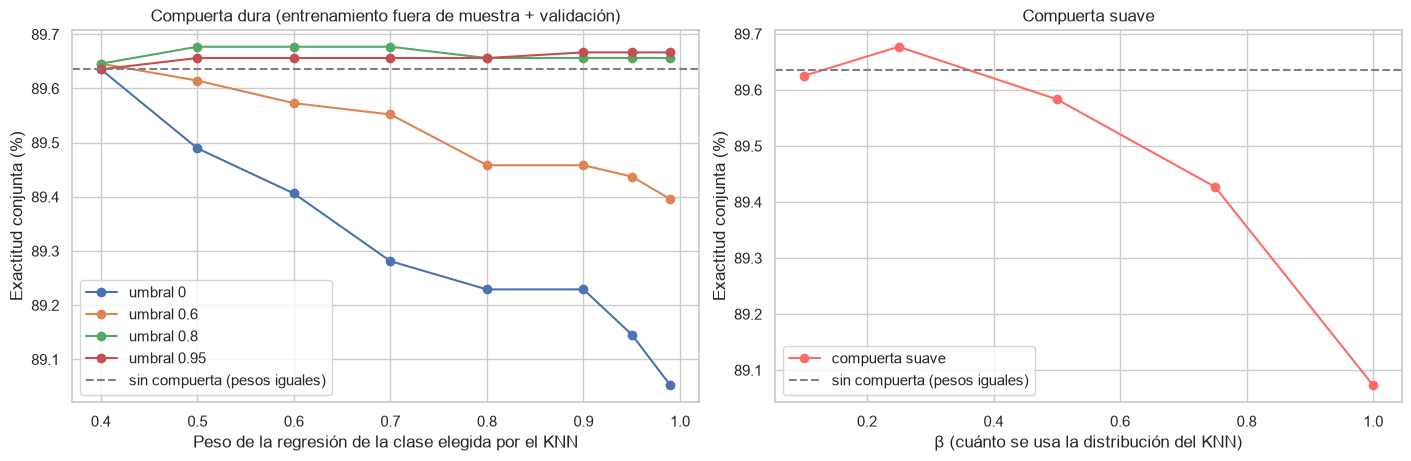

,Variante,peso,umbral,Exactitud entrenamiento (fuera de muestra),Exactitud validación,Exactitud conjunta,Diferencia vs sin compuerta (puntos),Error estándar (puntos),Reseñas corregidas,Reseñas dañadas
0,dura con umbral,0.70,0.80,0.8982,0.8925,0.8968,0.0417,0.0489,13,9
1,suave,0.25,0.00,0.8986,0.8912,0.8968,0.0417,0.0820,33,29
2,dura con umbral,0.60,0.80,0.8983,0.8921,0.8968,0.0417,0.0442,11,7
3,dura con umbral,0.50,0.80,0.8985,0.8917,0.8968,0.0417,0.0390,9,5
4,dura con umbral,0.99,0.95,0.8981,0.8925,0.8967,0.0312,0.0233,4,1
5,dura con umbral,0.95,0.95,0.8981,0.8925,0.8967,0.0312,0.0233,4,1
6,dura con umbral,0.90,0.95,0.8981,0.8925,0.8967,0.0312,0.0233,4,1
7,dura con umbral,0.50,0.95,0.8979,0.8925,0.8966,0.0208,0.0147,2,0
8,dura con umbral,0.90,0.80,0.8979,0.8925,0.8966,0.0208,0.0589,17,15
9,dura con umbral,0.80,0.95,0.8981,0.8921,0.8966,0.0208,0.0208,3,1


In [17]:
PESOS = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
UMBRALES = [0.0, 0.6, 0.8, 0.95]
BETAS = [0.1, 0.25, 0.5, 0.75, 1.0]

configuraciones = ([{'modo': 'dura', 'peso': p, 'umbral': u} for u in UMBRALES for p in PESOS]
                   + [{'modo': 'suave', 'peso': b, 'umbral': 0.0} for b in BETAS])


def evaluar_configuracion(cfg, P_bin=Pb_conj, P_knn=Pk_conj, y_real=y_conj):
    W = pesos_de(cfg['modo'], P_knn, cfg['peso'], cfg['umbral'])
    acierta = a_etiquetas(mezclar(P_bin, W)) == y_real
    return acierta


filas = []
for cfg in configuraciones:
    acierta = evaluar_configuracion(cfg)
    diferencia = acierta.astype(float) - acierta_base
    filas.append({**cfg, 'Exactitud entrenamiento (fuera de muestra)': acierta[:n_ent].mean(),
                  'Exactitud validación': acierta[n_ent:].mean(), 'Exactitud conjunta': acierta.mean(),
                  'Diferencia vs sin compuerta (puntos)': 100 * diferencia.mean(),
                  'Error estándar (puntos)': 100 * diferencia.std(ddof=1) / np.sqrt(len(diferencia)),
                  'Reseñas corregidas': int(((acierta == 1) & (acierta_base == 0)).sum()),
                  'Reseñas dañadas': int(((acierta == 0) & (acierta_base == 1)).sum())})
tabla_cfg = pd.DataFrame(filas)
tabla_cfg['Variante'] = np.where(tabla_cfg['modo'] == 'suave', 'suave',
                                 np.where(tabla_cfg['umbral'] == 0, 'dura', 'dura con umbral'))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
base = 100 * acierta_base.mean()
for umbral, grupo in tabla_cfg[tabla_cfg['modo'] == 'dura'].groupby('umbral'):
    ax[0].plot(grupo['peso'], 100 * grupo['Exactitud conjunta'], marker='o', label=f'umbral {umbral:g}')
ax[0].axhline(base, color='gray', linestyle='--', label='sin compuerta (pesos iguales)')
ax[0].set(xlabel='Peso de la regresión de la clase elegida por el KNN', ylabel='Exactitud conjunta (%)',
          title='Compuerta dura (entrenamiento fuera de muestra + validación)')
ax[0].legend()
suave = tabla_cfg[tabla_cfg['modo'] == 'suave']
ax[1].plot(suave['peso'], 100 * suave['Exactitud conjunta'], marker='o', color='#FF6B6B', label='compuerta suave')
ax[1].axhline(base, color='gray', linestyle='--', label='sin compuerta (pesos iguales)')
ax[1].set(xlabel='β (cuánto se usa la distribución del KNN)', ylabel='Exactitud conjunta (%)', title='Compuerta suave')
ax[1].legend()
plt.show()

columnas = ['Variante', 'peso', 'umbral', 'Exactitud entrenamiento (fuera de muestra)', 'Exactitud validación', 'Exactitud conjunta',
            'Diferencia vs sin compuerta (puntos)', 'Error estándar (puntos)', 'Reseñas corregidas', 'Reseñas dañadas']
display(tabla_cfg.sort_values('Exactitud conjunta', ascending=False)[columnas].head(10).round(4).reset_index(drop=True))

In [18]:
# Exactitud conjunta de toda la rejilla (la tabla anterior solo muestra las 10 mejores)
pivote = tabla_cfg[tabla_cfg['modo'] == 'dura'].pivot(index='peso', columns='umbral', values='Exactitud conjunta')
pivote.columns = [f'umbral {c:g}' for c in pivote.columns]
print(f'Exactitud conjunta sin compuerta (pesos iguales): {acierta_base.mean():.4f}\n')
print('Compuerta dura (filas: peso de la clase elegida por el KNN):')
display(pivote.round(4))
print('Compuerta suave (β -> exactitud conjunta):', {float(b): round(float(a), 4) for b, a in zip(suave['peso'], suave['Exactitud conjunta'])})

Exactitud conjunta sin compuerta (pesos iguales): 0.8964

Compuerta dura (filas: peso de la clase elegida por el KNN):


,umbral 0,umbral 0.6,umbral 0.8,umbral 0.95
peso,,,,
0.40,0.8964,0.8965,0.8965,0.8964
0.50,0.8949,0.8961,0.8968,0.8966
0.60,0.8941,0.8957,0.8968,0.8966
0.70,0.8928,0.8955,0.8968,0.8966
0.80,0.8923,0.8946,0.8966,0.8966
0.90,0.8923,0.8946,0.8966,0.8967
0.95,0.8915,0.8944,0.8966,0.8967
0.99,0.8905,0.8940,0.8966,0.8967


Compuerta suave (β -> exactitud conjunta): {0.1: 0.8962, 0.25: 0.8968, 0.5: 0.8958, 0.75: 0.8943, 1.0: 0.8907}


In [19]:
# Idea original: compuerta dura sin umbral. Mejor variante: la mayor exactitud conjunta entre todas las configuraciones.
# En ambos casos se excluye "sin compuerta", que es el punto de comparación.
def a_cfg(fila):
    return {'modo': fila['modo'], 'peso': float(fila['peso']), 'umbral': float(fila['umbral'])}


cfg_original = a_cfg(tabla_cfg[tabla_cfg['Variante'] == 'dura'].sort_values('Exactitud conjunta', ascending=False).iloc[0])
cfg_mejor = a_cfg(tabla_cfg.sort_values('Exactitud conjunta', ascending=False).iloc[0])
print('Idea original (compuerta dura, sin umbral):', cfg_original)
print('Mejor variante de la compuerta:            ', cfg_mejor)
for nombre, cfg in [('idea original', cfg_original), ('mejor variante', cfg_mejor)]:
    fila = tabla_cfg[(tabla_cfg['modo'] == cfg['modo']) & (tabla_cfg['peso'] == cfg['peso']) & (tabla_cfg['umbral'] == cfg['umbral'])].iloc[0]
    print(f'  {nombre}: {fila["Diferencia vs sin compuerta (puntos)"]:+.3f} puntos frente a no tener compuerta '
          f'(error estándar {fila["Error estándar (puntos)"]:.3f}); corrige {fila["Reseñas corregidas"]} y daña {fila["Reseñas dañadas"]} de {len(y_conj)} reseñas')

Idea original (compuerta dura, sin umbral): {'modo': 'dura', 'peso': 0.4, 'umbral': 0.0}
Mejor variante de la compuerta:             {'modo': 'dura', 'peso': 0.7, 'umbral': 0.8}
  idea original: +0.000 puntos frente a no tener compuerta (error estándar 0.097); corrige 43 y daña 43 de 9600 reseñas
  mejor variante: +0.042 puntos frente a no tener compuerta (error estándar 0.049); corrige 13 y daña 9 de 9600 reseñas


**Sin compuerta**, con las 9.600 predicciones fuera de muestra, las tres regresiones aciertan el **0,8964**. Lo que cambia al agregar la compuerta (tabla de la rejilla completa):

- **Compuerta dura, sin umbral (la idea original).** La exactitud **baja** a medida que sube el peso de la regresión elegida por el KNN: 0,8964 con peso 0,4 (casi pesos iguales), 0,8949 con 0,5, 0,8928 con 0,7 y 0,8905 con 0,99. Cada vez que el KNN se equivoca arrastra a la mezcla, y se equivoca en más de 1 de cada 5 reseñas. El mejor peso de la rejilla es el más bajo (0,4), y con él la compuerta **corrige 43 reseñas y daña 43**: el resultado es idéntico a no tener compuerta (+0,000 puntos, error estándar 0,097).
- **Compuerta dura con umbral.** Si el KNN solo opina cuando su probabilidad es de al menos 0,8 o 0,95, el daño desaparece (la exactitud queda en 0,8966 a 0,8968 para casi cualquier peso), pero tampoco hay mejora. La mejor configuración (varias empatan en 0,8968; se toma la primera, peso 0,7 y umbral 0,8) gana **+0,04 puntos con error estándar de 0,05**: corrige 13 reseñas y daña 9 de 9.600. Eso es ruido.
- **Compuerta suave.** El mejor valor es β = 0,25 (0,8968, también +0,04 puntos) y con β = 1 la exactitud cae a 0,8907.

Ninguna configuración se distingue de no tener compuerta. Para el resto del notebook se usan dos: la **idea original** (peso 0,4, sin umbral), que es el modelo que se entrega, y la **mejor variante** medida (peso 0,7, umbral 0,8), para ver si la diferencia mínima de arriba se sostiene fuera de muestra.

## 7. Diagnóstico: cuándo ayuda la compuerta y cuál es su techo

Para entender el resultado de la sección anterior se miran, con las 9.600 predicciones fuera de muestra, tres cosas:

1. **¿Dónde acierta el KNN?** La compuerta solo puede mejorar a las regresiones en las reseñas donde ellas dudan o fallan; ahí el KNN tendría que acertar bastante más que ellas.
2. **¿Cuándo acierta el KNN según su propia confianza?** Si el KNN es fiable cuando sus vecinos están de acuerdo, un umbral debería ayudar.
3. **El techo de la idea:** qué exactitud se obtendría con una compuerta **perfecta** (que "sabe" la clase real), con el mismo mecanismo de pesos. Es el máximo que cualquier KNN podría aportar.

In [20]:
acierta_reg = a_etiquetas(Pb_conj) == y_conj
acierta_knn = a_etiquetas(Pk_conj) == y_conj
Pn = Pb_conj / Pb_conj.sum(axis=1, keepdims=True)
ordenadas = np.sort(Pn, axis=1)
margen_reg = ordenadas[:, -1] - ordenadas[:, -2]           # diferencia entre la regresión más segura y la segunda
confianza_knn = Pk_conj.max(axis=1)

print(f'Exactitud: tres regresiones {acierta_reg.mean():.4f} | KNN {acierta_knn.mean():.4f}')
print(f'El KNN acierta el {100 * acierta_knn[~acierta_reg].mean():.1f}% de las reseñas que las regresiones fallan '
      f'y el {100 * acierta_knn[acierta_reg].mean():.1f}% de las que aciertan.')
print(f'Errores en común: el KNN también falla el {100 * (~acierta_knn[~acierta_reg]).mean():.1f}% de los errores de las regresiones.\n')

filas = []
for desde, hasta in [(0, 0.1), (0.1, 0.3), (0.3, 0.6), (0.6, 1.01)]:
    m = (margen_reg >= desde) & (margen_reg < hasta)
    filas.append({'Margen de las regresiones': f'[{desde:g}, {min(hasta, 1):g}{"]" if hasta > 1 else ")"}', 'Reseñas': int(m.sum()),
                  'Exactitud tres regresiones': acierta_reg[m].mean(), 'Exactitud KNN': acierta_knn[m].mean()})
display(pd.DataFrame(filas).set_index('Margen de las regresiones').round(3))

filas = []
for desde, hasta in [(0, 0.6), (0.6, 0.8), (0.8, 0.95), (0.95, 1.01)]:
    m = (confianza_knn >= desde) & (confianza_knn < hasta)
    filas.append({'Confianza del KNN': f'[{desde:g}, {min(hasta, 1):g}{"]" if hasta > 1 else ")"}', 'Reseñas': int(m.sum()),
                  'Exactitud KNN': acierta_knn[m].mean(), 'Exactitud tres regresiones': acierta_reg[m].mean()})
display(pd.DataFrame(filas).set_index('Confianza del KNN').round(3))

Exactitud: tres regresiones 0.8964 | KNN 0.7789
El KNN acierta el 28.5% de las reseñas que las regresiones fallan y el 83.6% de las que aciertan.
Errores en común: el KNN también falla el 71.5% de los errores de las regresiones.



,Reseñas,Exactitud tres regresiones,Exactitud KNN
Margen de las regresiones,,,
"[0, 0.1)",436,0.555,0.450
"[0.1, 0.3)",783,0.534,0.488
"[0.3, 0.6)",970,0.704,0.565
"[0.6, 1]",7411,0.980,0.857


,Reseñas,Exactitud KNN,Exactitud tres regresiones
Confianza del KNN,,,
"[0, 0.6)",2366,0.578,0.847
"[0.6, 0.8)",3126,0.734,0.872
"[0.8, 0.95)",2300,0.903,0.923
"[0.95, 1]",1808,0.961,0.970


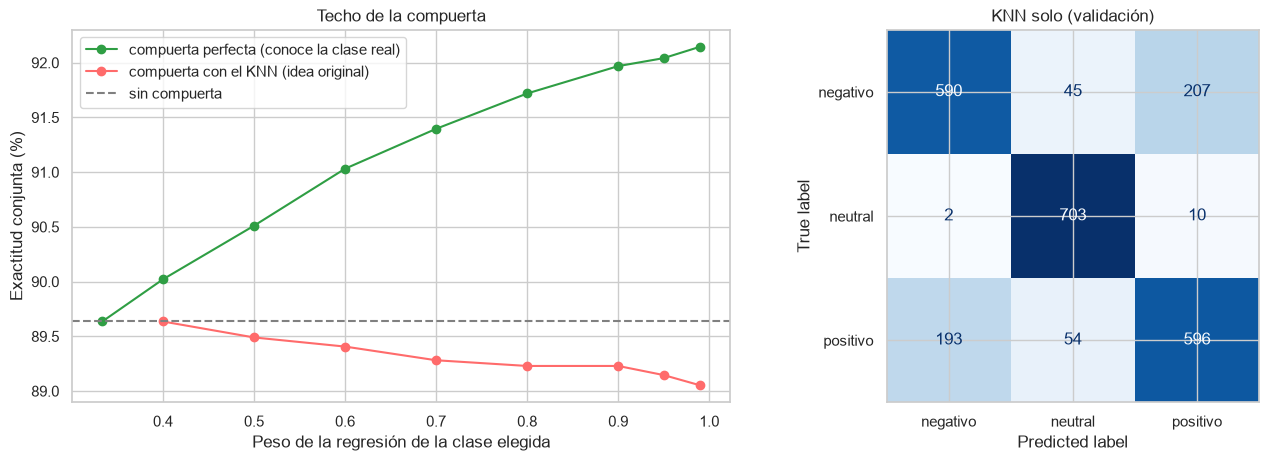

Exactitud con compuerta perfecta según el peso: {0.33: np.float64(0.8964), 0.4: np.float64(0.9002), 0.5: np.float64(0.9051), 0.6: np.float64(0.9103), 0.7: np.float64(0.914), 0.8: np.float64(0.9172), 0.9: np.float64(0.9197), 0.95: np.float64(0.9204), 0.99: np.float64(0.9215)}


In [21]:
# Techo de la idea: compuerta perfecta (el "KNN" conoce la clase real)
clase_real = np.searchsorted(ORDEN_CLASES, y_conj)
P_perfecto = np.eye(3)[clase_real]
pesos_techo = [1 / 3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
techo = [(a_etiquetas(mezclar(Pb_conj, pesos_compuerta_dura(P_perfecto, p))) == y_conj).mean() for p in pesos_techo]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
ax[0].plot(pesos_techo, 100 * np.array(techo), marker='o', color='#2F9E44', label='compuerta perfecta (conoce la clase real)')
datos_orig = tabla_cfg[tabla_cfg['Variante'] == 'dura']
ax[0].plot(datos_orig['peso'], 100 * datos_orig['Exactitud conjunta'], marker='o', color='#FF6B6B', label='compuerta con el KNN (idea original)')
ax[0].axhline(100 * acierta_base.mean(), color='gray', linestyle='--', label='sin compuerta')
ax[0].set(xlabel='Peso de la regresión de la clase elegida', ylabel='Exactitud conjunta (%)', title='Techo de la compuerta')
ax[0].legend()
ConfusionMatrixDisplay.from_predictions(y_val, a_etiquetas(Pk_val), labels=ORDEN_CLASES, cmap='Blues', ax=ax[1], colorbar=False)
ax[1].set_title('KNN solo (validación)')
plt.show()
print('Exactitud con compuerta perfecta según el peso:', dict(zip([round(p, 2) for p in pesos_techo], np.round(techo, 4))))

**¿Dónde acierta el KNN?** En ningún lugar donde importe:

- Acierta el 77,9% de las reseñas, frente al 89,6% de las regresiones. Solo acierta el **28,5%** de las reseñas que las regresiones fallan: **comparte el 71,5% de sus errores**, así que casi todo lo que las regresiones no resuelven, el KNN tampoco.
- En las reseñas **donde las regresiones dudan** (margen menor a 0,3 entre las dos regresiones más seguras: 1.219 de 9.600) las regresiones aciertan el 53 al 56% y el KNN el 45 al 49%. Es decir, ahí el KNN también es peor, no mejor.
- Donde el KNN está muy seguro (probabilidad de al menos 0,95, 1.808 reseñas) acierta el 96,1%, pero las regresiones ya aciertan el 97,0% en esas mismas reseñas. No hay una zona de confianza del KNN en la que supere a las regresiones, y por eso un umbral no puede ayudar.

**El techo de la idea.** Si la compuerta fuera **perfecta** (supiera la clase real), el mismo mecanismo de pesos subiría la exactitud de 0,8964 a 0,9051 con peso 0,5, 0,9140 con peso 0,7 y 0,9215 con peso 0,99. O sea que **la idea de pesar dinámicamente a las regresiones sí tiene espacio de mejora (hasta 2,5 puntos)**, pero ese espacio depende totalmente de la calidad de quien decide el peso, y un KNN que acierta 78% y se equivoca en las mismas reseñas que las regresiones no la tiene. La matriz de confusión del KNN (derecha) muestra que su principal falla es justo la que importa: confunde `negativo` con `positivo` (207 y 193 reseñas de 2.400 en validación), la misma confusión que cuesta a las regresiones.

## 8. Sesgo y varianza

Igual que en la Mejora 8, se compara la exactitud en entrenamiento con la de validación. Hay una precaución con el KNN y con la compuerta: si se les pide predecir las propias reseñas de entrenamiento, el KNN encuentra cada reseña como su vecina más cercana (distancia 0) y la exactitud en entrenamiento sale inflada artificialmente. Por eso, para el KNN y la compuerta se reporta la exactitud **fuera de muestra** del entrenamiento (sección 6.4); para las regresiones se reportan ambas.

In [22]:
cfg = cfg_original
W_val = pesos_de(cfg['modo'], Pk_val, cfg['peso'], cfg['umbral'])
W_oof = pesos_de(cfg['modo'], Pk_oof, cfg['peso'], cfg['umbral'])
P_comp_val = mezclar(Pb_val, W_val)
P_comp_oof = mezclar(Pb_oof, W_oof)

Pb_ent_ajuste = p_binarias(tres_nb, X_train)               # las regresiones evaluadas sobre sus propios datos
filas = [
    {'Modelo': 'Tres regresiones (NB-LR)', 'Entrenamiento (ajuste)': accuracy_score(y_train, a_etiquetas(Pb_ent_ajuste)),
     'Entrenamiento (fuera de muestra)': accuracy_score(y_train, a_etiquetas(Pb_oof)), 'Validación': accuracy_score(y_val, a_etiquetas(Pb_val))},
    {'Modelo': 'KNN coseno', 'Entrenamiento (ajuste)': np.nan,
     'Entrenamiento (fuera de muestra)': accuracy_score(y_train, a_etiquetas(Pk_oof)), 'Validación': accuracy_score(y_val, a_etiquetas(Pk_val))},
    {'Modelo': 'Compuerta KNN (idea original)', 'Entrenamiento (ajuste)': np.nan,
     'Entrenamiento (fuera de muestra)': accuracy_score(y_train, a_etiquetas(P_comp_oof)), 'Validación': accuracy_score(y_val, a_etiquetas(P_comp_val))},
]
tabla_sesgo = pd.DataFrame(filas).set_index('Modelo')
tabla_sesgo['Diferencia (ajuste - validación)'] = tabla_sesgo['Entrenamiento (ajuste)'] - tabla_sesgo['Validación']
display(tabla_sesgo.round(4))

# Sesgo entre clases en validación: proporción predicha de cada clase y sensibilidad (recall) por clase
filas = [{'Modelo': 'Real (validación)', **{f'% {c}': (y_val_arr == c).mean() for c in ORDEN_CLASES}}]
for nombre, P in [('Tres regresiones (NB-LR)', Pb_val), ('KNN coseno', Pk_val), ('Compuerta KNN (idea original)', P_comp_val)]:
    pred = a_etiquetas(P)
    fila = {'Modelo': nombre, **{f'% {c}': (pred == c).mean() for c in ORDEN_CLASES}}
    fila['negativo → positivo'] = int(((y_val_arr == 'negativo') & (pred == 'positivo')).sum())
    fila['positivo → negativo'] = int(((y_val_arr == 'positivo') & (pred == 'negativo')).sum())
    fila.update({f'Sensibilidad {c}': ((pred == c) & (y_val_arr == c)).sum() / (y_val_arr == c).sum() for c in ORDEN_CLASES})
    filas.append(fila)
pd.DataFrame(filas).set_index('Modelo').round(3)

,Entrenamiento (ajuste),Entrenamiento (fuera de muestra),Validación,Diferencia (ajuste - validación)
Modelo,,,,
Tres regresiones (NB-LR),0.9875,0.8976,0.8925,0.095
KNN coseno,NaN,0.7761,0.7871,NaN
Compuerta KNN (idea original),NaN,0.8981,0.8912,NaN


,% negativo,% neutral,% positivo,negativo → positivo,positivo → negativo,Sensibilidad negativo,Sensibilidad neutral,Sensibilidad positivo
Modelo,,,,,,,,
Real (validación),0.351,0.298,0.351,NaN,NaN,NaN,NaN,NaN
Tres regresiones (NB-LR),0.338,0.306,0.356,131.0,108.0,0.835,1.000,0.859
KNN coseno,0.327,0.334,0.339,207.0,193.0,0.701,0.983,0.707
Compuerta KNN (idea original),0.337,0.305,0.358,134.0,108.0,0.831,0.999,0.860


**Varianza.** Las tres regresiones tienen el patrón de siempre: 0,9875 al evaluarlas sobre sus propios datos de entrenamiento, 0,8976 fuera de muestra y 0,8925 en validación (una diferencia de 9,5 puntos entre ajuste y validación). Sesgo bajo y varianza alta, igual que NB-LR en la Mejora 8. El KNN es peor en ambos sentidos: acierta solo 0,78 fuera de muestra, y en la Mejora 8 ese mismo KNN acertaba el 100% de las reseñas de entrenamiento (porque cada una se encuentra a sí misma como vecina) y 0,7871 en validación. La compuerta hereda el patrón de las regresiones (0,8981 fuera de muestra y 0,8912 en validación) y no lo reduce.

**Sesgo entre clases.** La compuerta conserva el sesgo leve hacia `positivo` de NB-LR (35,8% de reseñas predichas como positivas frente a 35,1% real; 134 negativas clasificadas como positivas frente a 108 al revés) y no lo corrige. El KNN solo es más sesgado: predice 33,4% de reseñas como neutrales (29,8% real) y confunde unas 200 reseñas en cada sentido entre `negativo` y `positivo`, con sensibilidades de 0,70 en ambas clases.

## 9. Comparación en validación con los modelos que ya teníamos

Para comparar de forma justa, los modelos anteriores se vuelven a entrenar **con la misma partición** (solo con el conjunto de entrenamiento), con las mismas grillas e hiperparámetros de la Mejora 8:

- **Regresión logística** (L1, sobre la representación por bloques): el mejor modelo base de la Mejora 8.
- **Dos etapas + NB-LR**, con los hiperparámetros de la Mejora 7. Tarda más de un minuto porque incluye una validación cruzada interna.
- **Votación suave de los 2 mejores** (regresión logística y dos etapas + NB-LR): el mejor modelo de la Mejora 8 en validación y en prueba.

Las tres regresiones sin compuerta (pesos iguales) equivalen a "NB-LR con negación" de la Mejora 8.

In [23]:
inicio = time.time()
busqueda_lr = GridSearchCV(
    Pipeline([('rep', construir_representacion_corregida()),
              ('modelo', LogisticRegression(penalty='l1', solver='saga', max_iter=3000, random_state=RANDOM_STATE))]),
    {'modelo__C': [1, 3, 10, 30], 'modelo__class_weight': [None, 'balanced']},
    cv=kfold, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
regresion_logistica = busqueda_lr.best_estimator_
print(f'Regresión logística: {busqueda_lr.best_params_} | exactitud CV {busqueda_lr.best_score_:.4f} | {time.time() - inicio:.0f} s')

inicio = time.time()
dos_etapas = ModeloDosEtapasNBLR(C_etapa2=0.1).fit(X_train, y_train)
print(f'Dos etapas + NB-LR: hiperparámetros de la Mejora 7 | {time.time() - inicio:.0f} s')

Regresión logística: {'modelo__C': 3, 'modelo__class_weight': None} | exactitud CV 0.8938 | 627 s


Dos etapas + NB-LR: hiperparámetros de la Mejora 7 | 51 s


,Exactitud,Precisión,Sensibilidad,F1,AUC,AP
Votación suave (2 mejores),0.8975,0.9020,0.9025,0.9021,0.9828,0.9702
Dos etapas + NB-LR,0.8962,0.9007,0.9013,0.9009,0.9801,0.9622
Tres regresiones sin compuerta (NB-LR),0.8925,0.8959,0.8979,0.8967,0.9794,0.9626
Compuerta KNN (mejor variante),0.8925,0.8960,0.8979,0.8968,0.9733,0.9434
Compuerta KNN (idea original),0.8912,0.8949,0.8967,0.8956,0.9790,0.9601
Regresión logística,0.8908,0.8948,0.8959,0.8951,0.9814,0.9676
KNN coseno solo,0.7871,0.7871,0.7970,0.7906,0.9180,0.8475


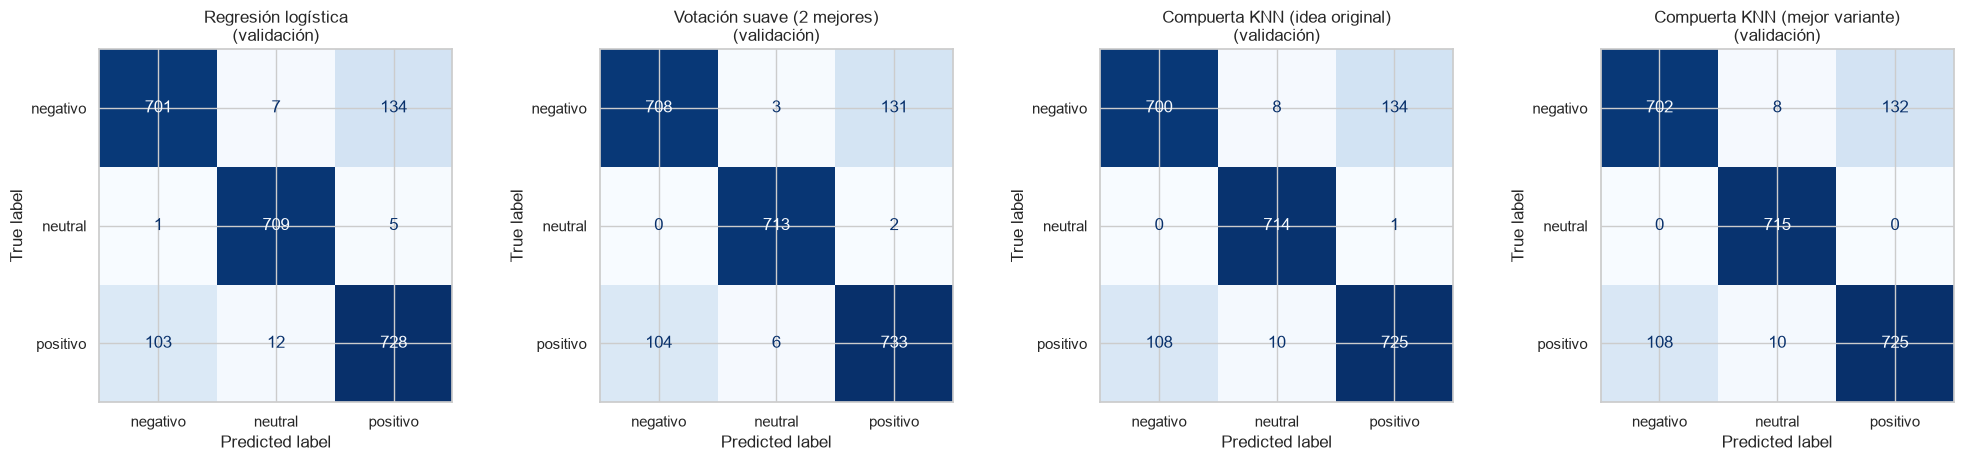

In [24]:
NOMBRE_ORIGINAL = 'Compuerta KNN (idea original)'
NOMBRE_MEJOR = 'Compuerta KNN (mejor variante)'
misma_config = cfg_original == cfg_mejor


def probabilidades_modelos(Pb, Pk, lr_prob, dos_prob):
    """Probabilidades de todos los modelos comparados sobre un conjunto (validación o prueba)."""
    prob_ = {'Regresión logística': lr_prob,
             'Tres regresiones sin compuerta (NB-LR)': Pb / Pb.sum(axis=1, keepdims=True),
             'KNN coseno solo': Pk,
             'Dos etapas + NB-LR': dos_prob,
             'Votación suave (2 mejores)': (lr_prob + dos_prob) / 2,
             NOMBRE_ORIGINAL: mezclar(Pb, pesos_de(cfg_original['modo'], Pk, cfg_original['peso'], cfg_original['umbral']))}
    if not misma_config:
        prob_[NOMBRE_MEJOR] = mezclar(Pb, pesos_de(cfg_mejor['modo'], Pk, cfg_mejor['peso'], cfg_mejor['umbral']))
    return prob_


prob_val = probabilidades_modelos(Pb_val, Pk_val, regresion_logistica.predict_proba(X_val), dos_etapas.predict_proba(X_val))
tabla_val = pd.DataFrame({n: metricas(y_val, p) for n, p in prob_val.items()}).T.sort_values('Exactitud', ascending=False)
display(tabla_val.round(4))

nombres_graf = ['Regresión logística', 'Votación suave (2 mejores)', NOMBRE_ORIGINAL] + ([] if misma_config else [NOMBRE_MEJOR])
fig, ax = plt.subplots(1, len(nombres_graf), figsize=(5 * len(nombres_graf), 4.5), constrained_layout=True)
for eje, nombre in zip(np.atleast_1d(ax), nombres_graf):
    ConfusionMatrixDisplay.from_predictions(y_val, a_etiquetas(prob_val[nombre]), labels=ORDEN_CLASES, cmap='Blues', ax=eje, colorbar=False)
    eje.set_title(f'{nombre}\n(validación)')
plt.show()

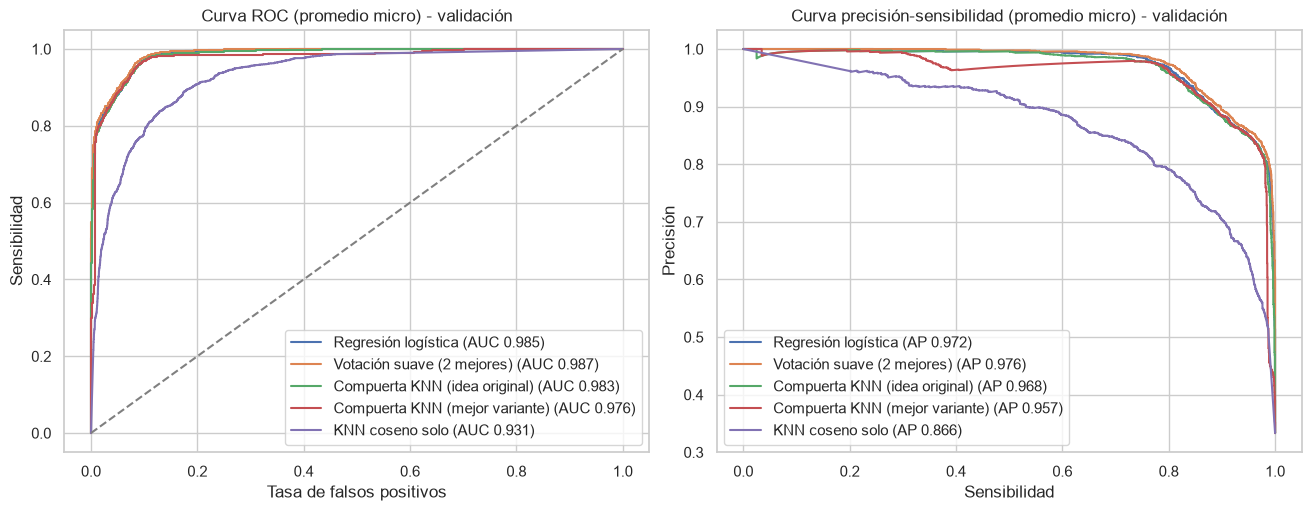

In [25]:
def curva_micro(y_real, probabilidades):
    Y = label_binarize(y_real, classes=ORDEN_CLASES)
    return Y.ravel(), probabilidades.ravel()


fig, ax = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for nombre in nombres_graf + ['KNN coseno solo']:
    y_bin, p = curva_micro(y_val, prob_val[nombre])
    fpr, tpr, _ = roc_curve(y_bin, p)
    precision, sensibilidad, _ = precision_recall_curve(y_bin, p)
    ax[0].plot(fpr, tpr, label=f'{nombre} (AUC {roc_auc_score(y_bin, p):.3f})')
    ax[1].plot(sensibilidad, precision, label=f'{nombre} (AP {average_precision_score(y_bin, p):.3f})')
ax[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[0].set(title='Curva ROC (promedio micro) - validación', xlabel='Tasa de falsos positivos', ylabel='Sensibilidad')
ax[1].set(title='Curva precisión-sensibilidad (promedio micro) - validación', xlabel='Sensibilidad', ylabel='Precisión')
ax[0].legend(loc='lower right')
ax[1].legend(loc='lower left')
plt.show()

En validación, la **votación suave de los 2 mejores es el mejor modelo (0,8975)**, seguida de dos etapas + NB-LR (0,8962). Las tres regresiones sin compuerta (0,8925) quedan por encima de la compuerta de la idea original (**0,8912**) y empatan con la mejor variante (0,8925). Es decir, **la compuerta no mejora a las regresiones que ya tiene dentro**: con la idea original pierde 3 reseñas de 2.400 y queda 0,63 puntos debajo de la votación suave (15 reseñas, del orden del error estándar de la validación). Además la compuerta empeora levemente el ordenamiento de las probabilidades (AUC 0,9790 y AP 0,9601, frente a 0,9794 y 0,9626 sin compuerta). En la mejor variante el efecto es mayor (AUC 0,9733 y AP 0,9434), probablemente porque el umbral hace que los pesos cambien de golpe entre reseñas muy parecidas. El KNN solo queda en 0,7871.

**Diferencias con la tabla de la Mejora 8.** Aquí se reentrenaron los modelos de referencia con la misma partición, pero no todas las cifras coinciden con las de aquel notebook. El modelo NB-LR (0,8976 en validación cruzada), el KNN (0,7761) y los hiperparámetros de ambos son idénticos. En cambio, la regresión logística L1 con `saga` eligió `C = 3` (0,8938 en validación cruzada, 0,8908 en validación) y no `C = 10` (0,8953 y 0,8967 en la Mejora 8, cuya versión guardada en el repositorio se ejecutó con Python 3.9.18), y la votación suave obtiene 0,8975 en lugar de 0,8996. La diferencia de hasta 0,6 puntos viene de esa regresión. Este notebook se ejecutó con Python 3.13.14 y scikit-learn 1.8.0, y no se comprobó si la versión de la librería explica el cambio. Además, con scikit-learn 1.8 `liblinear` ya no admite más de dos clases y el modelo en dos etapas de la Mejora 8 falla tal como está escrito (por eso el cambio de la sección 3). No cambia la lectura: todas las comparaciones de este notebook usan los mismos datos, la misma partición y el mismo entorno.

## 10. Evaluación en el conjunto de prueba

Todas las decisiones (representación y vecinos del KNN, hiperparámetros de las regresiones, peso y umbral de la compuerta) ya están tomadas con entrenamiento y validación. Aquí el conjunto de prueba se usa **una sola vez**, para los modelos de la tabla anterior.

Como las diferencias esperadas son de unas pocas reseñas, además de la exactitud se hace un **bootstrap pareado**: se remuestrean con reemplazo las 2.400 reseñas de prueba 10.000 veces y se calcula en cada remuestreo la diferencia de exactitud entre la compuerta y cada modelo de referencia. Se reporta el intervalo del 95% y el porcentaje de remuestreos en que la compuerta gana (como en la Mejora 6).

In [26]:
Pb_test = p_binarias(tres_nb, X_test)
Pk_test = knn.predict_proba(X_test)
prob_test = probabilidades_modelos(Pb_test, Pk_test, regresion_logistica.predict_proba(X_test), dos_etapas.predict_proba(X_test))

filas = []
for nombre in prob_val:
    filas.append({'Modelo': nombre, 'Exactitud validación': metricas(y_val, prob_val[nombre])['Exactitud'], **metricas(y_test, prob_test[nombre])})
tabla_test = pd.DataFrame(filas).set_index('Modelo').rename(columns={'Exactitud': 'Exactitud prueba', 'Precisión': 'Precisión prueba',
                                                                       'Sensibilidad': 'Sensibilidad prueba', 'F1': 'F1 prueba',
                                                                       'AUC': 'AUC prueba', 'AP': 'AP prueba'})
display(tabla_test.sort_values('Exactitud prueba', ascending=False).round(4))

y_test_arr = y_test.values
pred_test = {n: a_etiquetas(p) for n, p in prob_test.items()}


def bootstrap_pareado(acierta_a, acierta_b, repeticiones=10000, bloque=500):
    rng = np.random.default_rng(RANDOM_STATE)
    n = len(acierta_a)
    dif = np.concatenate([(acierta_a[idx].mean(axis=1) - acierta_b[idx].mean(axis=1))
                          for idx in (rng.integers(0, n, size=(bloque, n)) for _ in range(repeticiones // bloque))])
    return dif.mean(), np.percentile(dif, [2.5, 97.5]), (dif > 0).mean()


filas = []
acierta_principal = pred_test[NOMBRE_ORIGINAL] == y_test_arr
for referencia in ['Tres regresiones sin compuerta (NB-LR)', 'Regresión logística', 'Dos etapas + NB-LR', 'Votación suave (2 mejores)']:
    acierta_ref = pred_test[referencia] == y_test_arr
    media, (bajo, alto), p_gana = bootstrap_pareado(acierta_principal, acierta_ref)
    filas.append({f'{NOMBRE_ORIGINAL} frente a': referencia, 'Diferencia (puntos)': 100 * media,
                  'Intervalo 95% (puntos)': f'[{100 * bajo:+.2f}, {100 * alto:+.2f}]', 'Gana en (% de remuestreos)': 100 * p_gana,
                  'Solo la compuerta acierta': int((acierta_principal & ~acierta_ref).sum()),
                  'Solo la referencia acierta': int((~acierta_principal & acierta_ref).sum())})
display(pd.DataFrame(filas).set_index(f'{NOMBRE_ORIGINAL} frente a').round(2))

,Exactitud validación,Exactitud prueba,Precisión prueba,Sensibilidad prueba,F1 prueba,AUC prueba,AP prueba
Modelo,,,,,,,
Tres regresiones sin compuerta (NB-LR),0.8925,0.9038,0.9071,0.9086,0.9078,0.9829,0.9684
Votación suave (2 mejores),0.8975,0.9033,0.9078,0.9081,0.9080,0.9837,0.9714
Compuerta KNN (idea original),0.8912,0.9029,0.9067,0.9078,0.9072,0.9817,0.9658
Compuerta KNN (mejor variante),0.8925,0.9021,0.9055,0.9070,0.9062,0.9771,0.9519
Dos etapas + NB-LR,0.8962,0.9012,0.9059,0.9062,0.9060,0.9815,0.9652
Regresión logística,0.8908,0.8983,0.9015,0.9030,0.9022,0.9826,0.9696
KNN coseno solo,0.7871,0.7879,0.7889,0.7976,0.7923,0.9179,0.8502


,Diferencia (puntos),Intervalo 95% (puntos),Gana en (% de remuestreos),Solo la compuerta acierta,Solo la referencia acierta
Compuerta KNN (idea original) frente a,,,,,
Tres regresiones sin compuerta (NB-LR),-0.08,"[-0.46, +0.29]",29.06,9,11
Regresión logística,0.45,"[-0.50, +1.46]",80.35,78,67
Dos etapas + NB-LR,0.17,"[-0.62, +0.92]",64.34,45,41
Votación suave (2 mejores),-0.04,"[-0.83, +0.79]",44.03,48,49


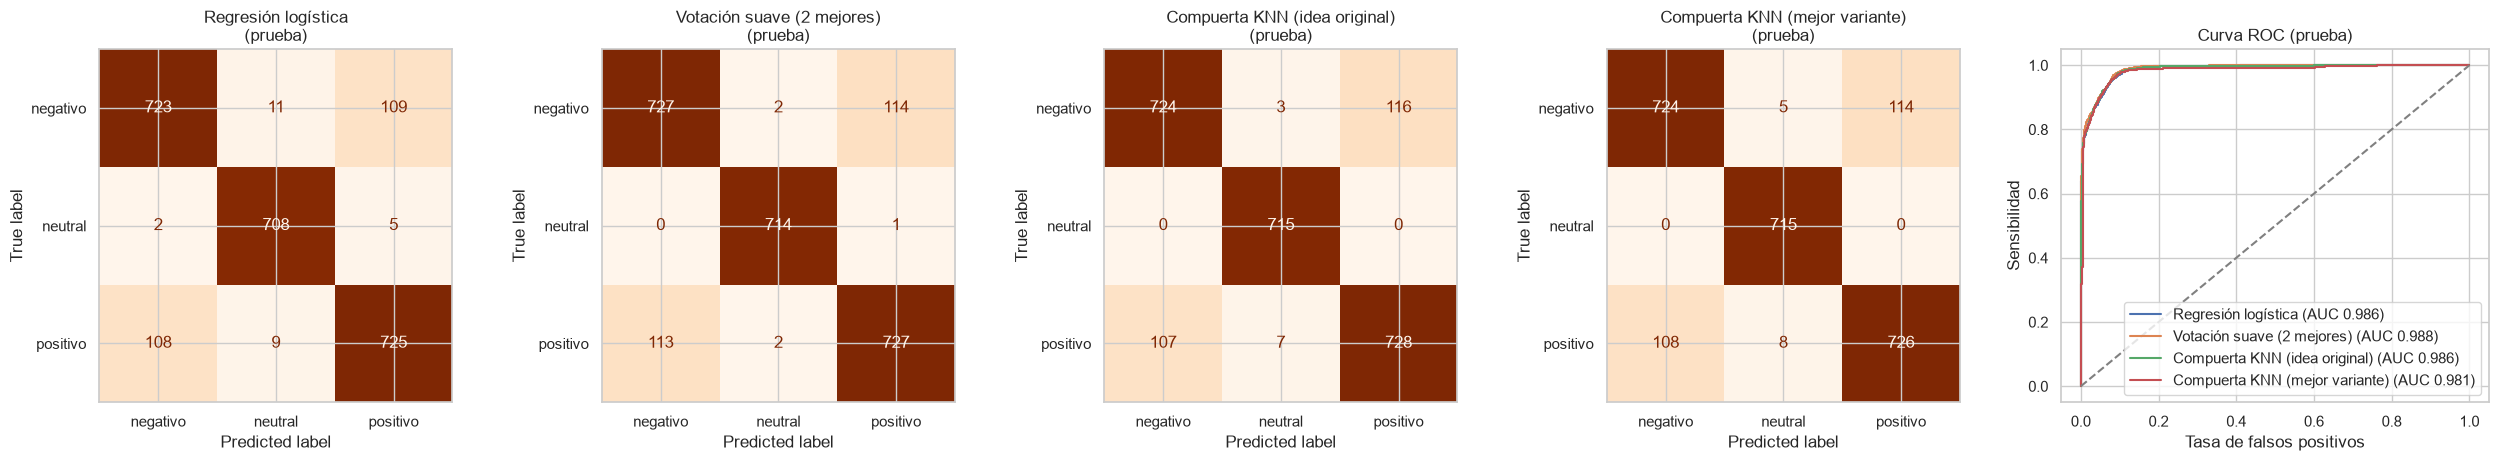

In [27]:
nombres_test = ['Regresión logística', 'Votación suave (2 mejores)', NOMBRE_ORIGINAL] + ([] if misma_config else [NOMBRE_MEJOR])
fig, ax = plt.subplots(1, len(nombres_test) + 1, figsize=(5 * (len(nombres_test) + 1), 4.5), constrained_layout=True)
for eje, nombre in zip(ax[:-1], nombres_test):
    ConfusionMatrixDisplay.from_predictions(y_test, pred_test[nombre], labels=ORDEN_CLASES, cmap='Oranges', ax=eje, colorbar=False)
    eje.set_title(f'{nombre}\n(prueba)')
for nombre in nombres_test:
    y_bin, p = curva_micro(y_test, prob_test[nombre])
    fpr, tpr, _ = roc_curve(y_bin, p)
    ax[-1].plot(fpr, tpr, label=f'{nombre} (AUC {roc_auc_score(y_bin, p):.3f})')
ax[-1].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[-1].set(title='Curva ROC (prueba)', xlabel='Tasa de falsos positivos', ylabel='Sensibilidad')
ax[-1].legend(loc='lower right')
plt.show()

En prueba, los modelos con NB-LR quedan todos muy juntos, entre 0,9012 y 0,9038, y no hay una diferencia que se pueda sostener:

- La compuerta de la **idea original** obtiene **0,9029**, frente a 0,9038 de las tres regresiones sin compuerta, 0,9033 de la votación suave de los 2 mejores y 0,9012 de dos etapas + NB-LR. La mejor variante obtiene 0,9021. La regresión logística sola queda en 0,8983 y el KNN en 0,7879.
- En el **bootstrap pareado** todos los intervalos del 95% incluyen el cero. La compuerta gana en el 29% de los remuestreos frente a las tres regresiones sin compuerta (diferencia de -0,08 puntos, 9 reseñas a favor y 11 en contra), en el 44% frente a la votación suave (-0,04 puntos) y en el 64% frente a dos etapas (+0,17 puntos). Frente a la regresión logística sola gana en el 80% (+0,45 puntos, intervalo de -0,50 a +1,46), pero esa ventaja viene de NB-LR: las tres regresiones sin compuerta tienen la misma ventaja (0,9038), así que no se debe a la compuerta.

Las cifras de prueba confirman lo que se vio en validación y en las predicciones fuera de muestra: **la compuerta KNN no mejora a NB-LR ni a los modelos que ya teníamos**; da lo mismo que no tenerla.

## 11. Modelo final y predicciones para la competencia

El modelo de esta mejora es la **compuerta KNN de la idea original** (compuerta dura sin umbral, con el peso elegido en la sección 6). Se empaqueta como una clase con la interfaz de scikit-learn, `ClasificadorCompuertaKNN`, que entrena las tres regresiones y el KNN y combina sus salidas con las mismas funciones (`mezclar` y `pesos_de`) usadas en las secciones anteriores. Se vuelve a entrenar con las 12.000 reseñas etiquetadas, sin buscar de nuevo los hiperparámetros, y con él se predicen las reseñas de `eval.csv`.

In [28]:
class ClasificadorCompuertaKNN(ClassifierMixin, BaseEstimator):
    """Tres regresiones logísticas (NB-LR) combinadas por voto suave con pesos que decide un KNN coseno.

    regresiones: Pipeline cuyo último paso es TresRegresionesLogisticas.
    knn: Pipeline con un KNeighborsClassifier(metric='cosine').
    modo, peso, umbral: ver pesos_de (en la compuerta suave, `peso` es beta).
    """

    def __init__(self, regresiones=None, knn=None, modo='dura', peso=0.5, umbral=0.0):
        self.regresiones = regresiones
        self.knn = knn
        self.modo = modo
        self.peso = peso
        self.umbral = umbral

    def fit(self, X, y):
        self.regresiones_ = clone(self.regresiones).fit(X, y)
        self.knn_ = clone(self.knn).fit(X, y)
        self.classes_ = self.regresiones_.classes_
        return self

    def componentes(self, X):
        return p_binarias(self.regresiones_, X), self.knn_.predict_proba(X)

    def predict_proba(self, X):
        P_bin, P_knn = self.componentes(X)
        return mezclar(P_bin, pesos_de(self.modo, P_knn, self.peso, self.umbral))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

In [29]:
NOMBRE_MODELO = 'samuel_knn_compuerta_tres_regresiones'

modelo_final = ClasificadorCompuertaKNN(regresiones=tres_nb, knn=knn, modo=cfg_original['modo'],
                                        peso=cfg_original['peso'], umbral=cfg_original['umbral'])
inicio = time.time()
modelo_final.fit(X, y)       # las 12.000 reseñas etiquetadas
print(f'Compuerta KNN entrenada con las 12.000 reseñas en {time.time() - inicio:.0f} s | '
      f'modo {modelo_final.modo}, peso {modelo_final.peso}, umbral {modelo_final.umbral}')

# La clase entrenada solo con entrenamiento debe dar lo mismo que las funciones usadas en las secciones 6 a 10
control = clone(modelo_final).fit(X_train, y_train)
print('La clase reproduce las probabilidades de la sección 10 (prueba):',
      np.allclose(control.predict_proba(X_test), prob_test[NOMBRE_ORIGINAL]))

pred_eval = modelo_final.predict(evaluacion[['text']])
envio = pd.DataFrame({'id': evaluacion['id'], 'answer': pred_eval})
envio.to_csv(os.path.join(RUTA_ENVIOS, f'submission_{NOMBRE_MODELO}.csv'), index=False)
print('Archivo:', f'submission_{NOMBRE_MODELO}.csv', '|', envio.shape)
print('Mismas columnas y mismos ids que sample_submission:',
      list(envio.columns) == list(muestra_envio.columns) and (envio['id'] == muestra_envio['id']).all())

for archivo in ['submission_votacion_suave_mejores.csv', 'submission_dos_etapas_nblr.csv', 'submission_nb_regresion_logistica.csv',
                'submission_regresion_logistica_ajuste_fino.csv', 'submission_regresion_logistica_bloques.csv']:
    ruta = os.path.join(RUTA_ENVIOS, archivo)
    if os.path.exists(ruta):
        print(f'Predicciones distintas respecto a {archivo}: {(envio["answer"] != pd.read_csv(ruta)["answer"]).sum()} de {len(envio)}')
display(pd.DataFrame({'train (real)': train['label'].value_counts(normalize=True),
                      'eval (predicho)': envio['answer'].value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3))

Compuerta KNN entrenada con las 12.000 reseñas en 6 s | modo dura, peso 0.4, umbral 0.0


La clase reproduce las probabilidades de la sección 10 (prueba): True


Archivo: submission_knn_compuerta_tres_regresiones.csv | (3000, 2)
Mismas columnas y mismos ids que sample_submission: True
Predicciones distintas respecto a submission_votacion_suave_mejores.csv: 131 de 3000
Predicciones distintas respecto a submission_dos_etapas_nblr.csv: 82 de 3000
Predicciones distintas respecto a submission_nb_regresion_logistica.csv: 52 de 3000
Predicciones distintas respecto a submission_regresion_logistica_ajuste_fino.csv: 172 de 3000
Predicciones distintas respecto a submission_regresion_logistica_bloques.csv: 192 de 3000


,train (real),eval (predicho)
negativo,0.351,0.352
neutral,0.298,0.282
positivo,0.351,0.366


In [30]:
ruta_modelo = os.path.join(RUTA_MODELOS, f'{NOMBRE_MODELO}.joblib')
joblib.dump(modelo_final, ruta_modelo)
modelo_cargado = joblib.load(ruta_modelo)
print('El modelo guardado reproduce exactamente las mismas predicciones:',
      (modelo_cargado.predict(evaluacion[['text']]) == pred_eval).all())
print(f'Tiempo total de ejecución del notebook: {(time.time() - INICIO_NOTEBOOK) / 60:.1f} minutos')

El modelo guardado reproduce exactamente las mismas predicciones: True
Tiempo total de ejecución del notebook: 13.3 minutos


El modelo final es casi NB-LR con un empujón suave hacia la clase que elige el KNN (peso 0,4 frente a 0,33 de pesos iguales), entrenado con las 12.000 reseñas en 6 segundos (los componentes son rápidos; lo lento del notebook son las referencias de las secciones 9 y 10). Su envío (`submission_samuel_knn_compuerta_tres_regresiones.csv`) cambia 131 de las 3.000 predicciones respecto al de la votación suave de la Mejora 8, 82 respecto al de dos etapas + NB-LR (el mejor puntaje público, 0,9077), 52 respecto al de NB-LR de la Mejora 7 y entre 172 y 192 respecto a los de regresión logística. La distribución de clases predicha (35,2% negativas, 28,2% neutrales, 36,6% positivas) es parecida a la de entrenamiento, con algo menos de neutrales y de nuevo un leve sesgo hacia `positivo`.

**Sobre este envío.** Como en prueba no hay diferencia con los demás modelos, no hay una razón basada en datos para preferirlo al envío de dos etapas + NB-LR ni al de la votación suave. Se genera por completitud y para poder medir su puntaje público. El archivo del modelo (`models/samuel_knn_compuerta_tres_regresiones.joblib`) pesa unos 43 MB porque el KNN guarda la matriz de entrenamiento completa.

## 12. Conclusiones

- **La compuerta KNN no mejora los resultados.** Con 9.600 predicciones fuera de muestra, la idea original (el KNN elige una clase y su regresión pesa más) deja la exactitud igual que sin compuerta en el mejor peso (0,8964; corrige 43 reseñas y daña 43) y la empeora a medida que se le da más peso (0,8905 con peso 0,99). Con umbral o con compuerta suave la mejor diferencia es de +0,04 puntos, que es ruido (error estándar de 0,05). En prueba, la idea original obtiene 0,9029, frente a 0,9038 de las tres regresiones sin compuerta y 0,9033 de la votación suave de los 2 mejores; todos los intervalos del bootstrap incluyen el cero.
- **Por qué no funciona.** El KNN acierta el 78% de las reseñas y comete el 71,5% de los errores de las regresiones. En las reseñas donde las regresiones dudan acierta menos que ellas (45 a 49% frente a 53 a 56%), y cuando está muy seguro las regresiones ya aciertan casi lo mismo (97%). No hay ninguna situación en la que su voto aporte información que las regresiones no tengan.
- **El techo de la idea es real, pero lo limita la compuerta.** Una compuerta perfecta subiría la exactitud hasta 0,92 (+2,5 puntos con peso 0,99). Pesar dinámicamente a las tres regresiones solo ayuda si quien decide el peso se equivoca en reseñas distintas a las de las regresiones, y un KNN sobre bolsas de palabras no lo hace.
- **Lo que sí aportó Naive Bayes con regresión logística.** Las tres regresiones con razón de Naive Bayes superan a las mismas tres sin ella en 2,5 puntos en validación cruzada (0,8976 frente a 0,8729) y en 1 punto en validación. La regresión de `neutral` es casi perfecta (AUC 0,9999): todo el error del problema está en separar `positivo` de `negativo`.
- **Para Kaggle.** No hay evidencia para preferir este envío. Los modelos que ya se tenían (dos etapas + NB-LR y la votación suave de los 2 mejores) rinden igual en prueba; las diferencias entre todos son de unas pocas reseñas de 2.400.
- **Si se quiere seguir con la idea.** Habría que cambiar quien decide el peso por algo que tenga información distinta a la de las regresiones (por ejemplo, un modelo que aprenda con las probabilidades fuera de muestra cuándo se equivocan las regresiones) y no repetir el mismo tipo de representación en bolsa de palabras.

## 13. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (modelo Claude Sonnet 5.5, de Anthropic) como apoyo para: proponer y generar un primer esqueleto del código de este notebook, depurar errores, ejecutar los experimentos y redactar las explicaciones.

**Prompts utilizados.**

1. Se explicó la idea del equipo y se pidió implementarla en un notebook siguiendo el notebook principal (Mejora 8): tres regresiones logísticas una contra el resto (positivo / no positivo, neutral / no neutral, negativo / no negativo); un KNN con distancia coseno, mezclado con el mejor modelo del grupo (Naive Bayes con regresión logística), que clasifica la reseña y elige una clase; y un voto suave en el que la regresión de la clase elegida por el KNN recibe el mayor peso, para ver si predice mejor que los modelos anteriores.

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

**Aportes propios del equipo.**

[Completar por el equipo: qué se desarrolló, modificó o decidió, qué ajustes se hicieron al código y a las explicaciones, y qué se aprendió del proceso.]

## 14. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (están en la raíz del proyecto). El notebook también corre con scikit-learn 1.8 (se ejecutó con Python 3.13.14, scikit-learn 1.8.0, numpy 2.5.2 y pandas 2.3.3); por eso la regresión L1 del modelo en dos etapas se envuelve en `OneVsRestClassifier` (ver la sección 3).
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/`, los datos en `data/`. El notebook se ejecuta desde la carpeta `notebooks/`.
3. Ejecutar todas las celdas en orden (`Restart & Run All`). Con el entorno de esta ejecución tarda unos 13 minutos, de los cuales unos 10 son la búsqueda de hiperparámetros de la regresión logística L1 con `saga` de la sección 9 (en la versión de la Mejora 8 guardada en el repositorio esa misma búsqueda tardó 35 segundos, con Python 3.9; no se determinó la causa). Las secciones 4 a 8, que son las de esta mejora, tardan menos de 2 minutos.
4. Al terminar se generan `models/samuel_knn_compuerta_tres_regresiones.joblib` y `submissions/submission_samuel_knn_compuerta_tres_regresiones.csv`.

Todas las fuentes de aleatoriedad usan semillas fijas, por lo que las cifras se reproducen con las mismas versiones de las librerías. Para cargar el modelo guardado fuera del notebook hay que ejecutar antes las celdas que definen las funciones y las clases (`NBRegresionLogistica`, `TresRegresionesLogisticas`, `PonderadorNB`, `ClasificadorCompuertaKNN`, `mezclar` y `pesos_de`) usadas por el pipeline.